<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/types_of_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv('homeprices_banglore.csv')
df.sample(5)

,area,bedrooms,price
1,2600,4,120.00
17,1540,3,60.00
0,1056,2,39.07
6,2732,4,135.00
8,1310,3,50.00


In [6]:
from sklearn import preprocessing

sx=preprocessing.MinMaxScaler()
sy=preprocessing.MinMaxScaler()

scaled_x=sx.fit_transform(df.drop('price',axis='columns'))
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [7]:
scaled_y=sy.fit_transform(df['price'].values.reshape(df.shape[0],1))
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [10]:
w=np.ones(shape=(2))

**BATCH GRADIENT DESCENT**

In [14]:
def batch_gradient_descent(x,y_true,epochs,learning_rate=0.01):
  number_of_feature=x.shape[1]

  w=np.ones(shape=(number_of_feature))
  b=0
  total_samples=x.shape[0]
  cost_list=[]
  epoch_list=[]

  for i in range(epochs):
    y_predicted=np.dot(w,scaled_x.T) +b

    w_grad=-(2/total_samples)*(y_true-y_predicted).dot(x)
    b_grad=-(2/total_samples)*np.sum(y_true-y_predicted)

    w=w-learning_rate*w_grad
    b=b-learning_rate*b_grad
    cost=np.mean(np.square(y_true-y_predicted))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)
  return w,b,cost,cost_list,epoch_list

w,b,cost,cost_list,epoch_list=batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),500)
w,b,cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

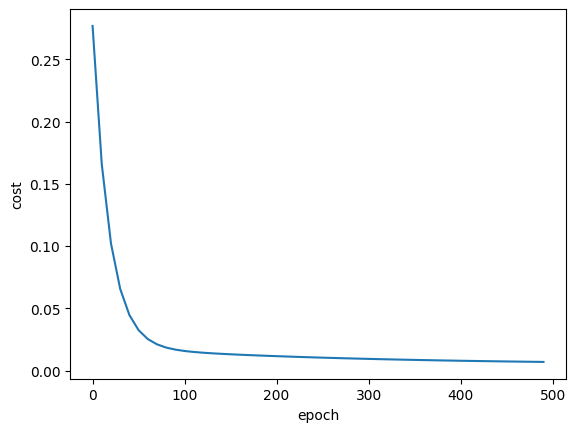

In [18]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [19]:
sx.transform([[1,2]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[-0.27551724,  0.25      ]])

In [21]:
def predict(area,bedrooms,w,b):
  scaled_x=sx.transform([[area,bedrooms]])[0]

  scaled_price=w[0]*scaled_x[0]+w[1]*scaled_x[1]+b
  return sy.inverse_transform([[scaled_price]])[0][0]

predict(2600,4,w,b)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

In [22]:
predict(1000,2,w,b)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442355)

**STOCHASTIC GRADIENT DESCENT**

In [26]:
import random

In [33]:
def batch_gradient_descent(x,y_true,epochs,learning_rate=0.01):
  number_of_feature=x.shape[1]

  w=np.ones(shape=(number_of_feature))
  b=0
  total_samples=x.shape[0]
  cost_list=[]
  epoch_list=[]

  for i in range(epochs):
    random_index=random.randint(0,total_samples-1)
    sample_x=x[random_index]
    sample_y=y_true[random_index]
    y_predicted=np.dot(w,sample_x.T) +b

    w_grad=-(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad=-(2/total_samples)*np.sum(sample_y-y_predicted)

    w=w-learning_rate*w_grad
    b=b-learning_rate*b_grad
    cost=np.square(sample_y-y_predicted)

    if i%100==0:
      cost_list.append(cost)
      epoch_list.append(i)
  return w,b,cost,cost_list,epoch_list

w_s,b_s,cost_s,cost_list_s,epoch_list_s=batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),10000)
w_s,b_s,cost_s

(array([0.70600709, 0.67229125]),
 np.float64(-0.2276096676835518),
 np.float64(0.002464732922522585))

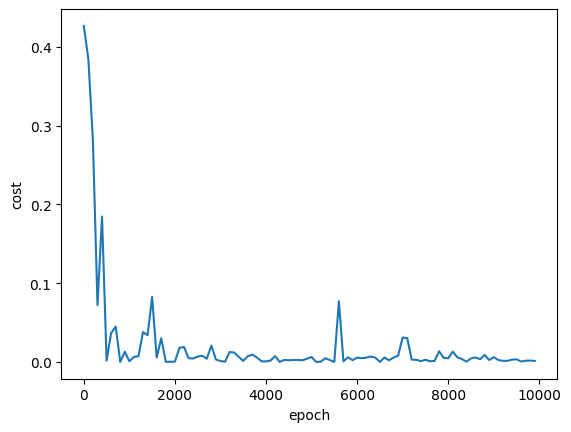

In [34]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_s,cost_list_s)

In [35]:
predict(2000,4,w_s,b_s)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(108.78120097030653)

In [43]:
def mini_batch_gradient_descent(x,y_true,epochs,batch_size=5,learning_rate=0.01):
  number_of_feature=x.shape[1]

  w=np.ones(shape=(number_of_feature))
  b=0
  total_samples=x.shape[0]
  if batch_size>total_samples:
    batch_size=total_samples

  cost_list=[]
  epoch_list=[]

  num_batches=int(total_samples/batch_size)

  for i in range(epochs):
    random_index=np.random.permutation(total_samples)
    x_shuffled=x[random_index]
    y_shuffled=y_true[random_index]
    for j in range(0,total_samples,batch_size):
      batch_x=x_shuffled[j:j+batch_size]
      batch_y=y_shuffled[j:j+batch_size]
      y_predicted=np.dot(batch_x,w) +b

      w_grad=-(2/len(batch_x))*(batch_x.T.dot(batch_y-y_predicted))
      b_grad=-(2/len(batch_x))*np.sum(batch_y-y_predicted)

      w=w-learning_rate*w_grad
      b=b-learning_rate*b_grad
      cost=np.mean(np.square(batch_y-y_predicted))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)
  return w,b,cost,cost_list,epoch_list

w_m,b_m,cost_m,cost_list_m,epoch_list_m=mini_batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),epochs=120,batch_size=5)
w_m,b_m,cost_m

(array([0.7100559 , 0.67814249]),
 np.float64(-0.23333843547805852),
 np.float64(0.004146911448799701))

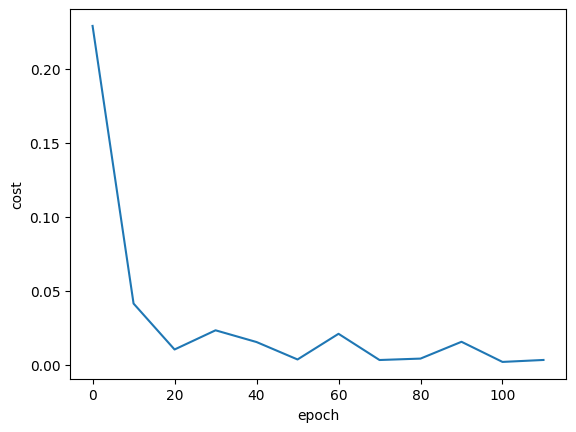

In [44]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_m,cost_list_m)